# What drives the price of a car?

![](images/kurt.jpeg)

**OVERVIEW**

In this application, you will explore a dataset from kaggle. The original dataset contained information on 3 million used cars. The provided dataset contains information on 426K cars to ensure speed of processing.  Your goal is to understand what factors make a car more or less expensive.  As a result of your analysis, you should provide clear recommendations to your client -- a used car dealership -- as to what consumers value in a used car.

### CRISP-DM Framework

<center>
    <img src = images/crisp.png width = 50%/>
</center>


To frame the task, throughout our practical applications we will refer back to a standard process in industry for data projects called CRISP-DM.  This process provides a framework for working through a data problem.  Your first step in this application will be to read through a brief overview of CRISP-DM [here](https://mo-pcco.s3.us-east-1.amazonaws.com/BH-PCMLAI/module_11/readings_starter.zip).  After reading the overview, answer the questions below.

### Business Understanding

From a business perspective, we are tasked with identifying key drivers for used car prices.  In the CRISP-DM overview, we are asked to convert this business framing to a data problem definition.  Using a few sentences, reframe the task as a data task with the appropriate technical vocabulary. 

The objective is to create a predictive model that assesses how different vehicle attributes—such as year, manufacturer, odometer reading, and condition—affect the price of used cars.

This process includes performing exploratory data analysis (EDA) to identify key features, followed by using regression techniques to model the relationship between these features and used car prices. The result will be a set of statistically significant features that act as primary drivers for predicting used car prices.

### Data Understanding

After considering the business understanding, we want to get familiar with our data.  Write down some steps that you would take to get to know the dataset and identify any quality issues within.  Take time to get to know the dataset and explore what information it contains and how this could be used to inform your business understanding.

To become familiar with data and identify any quality issues, consider below steps:

1. Review Dataset Documentation
2. Load Initil Data
3. Assess Missing Data
4. Explore Categorical and Numerical Features
5. Check for Duplicates

### Data Preparation

After our initial exploration and fine tuning of the business understanding, it is time to construct our final dataset prior to modeling.  Here, we want to make sure to handle any integrity issues and cleaning, the engineering of new features, any transformations that we believe should happen (scaling, logarithms, normalization, etc.), and general preparation for modeling with `sklearn`. 

In [201]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import numpy as np
import datetime

In [202]:
vehicle_df = pd.read_csv('data/vehicles.csv')

In [203]:
vehicle_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   region        426880 non-null  object 
 2   price         426880 non-null  int64  
 3   year          425675 non-null  float64
 4   manufacturer  409234 non-null  object 
 5   model         421603 non-null  object 
 6   condition     252776 non-null  object 
 7   cylinders     249202 non-null  object 
 8   fuel          423867 non-null  object 
 9   odometer      422480 non-null  float64
 10  title_status  418638 non-null  object 
 11  transmission  424324 non-null  object 
 12  VIN           265838 non-null  object 
 13  drive         296313 non-null  object 
 14  size          120519 non-null  object 
 15  type          334022 non-null  object 
 16  paint_color   296677 non-null  object 
 17  state         426880 non-null  object 
dtypes: f

In [204]:
vehicle_df.isnull().sum()

id                   0
region               0
price                0
year              1205
manufacturer     17646
model             5277
condition       174104
cylinders       177678
fuel              3013
odometer          4400
title_status      8242
transmission      2556
VIN             161042
drive           130567
size            306361
type             92858
paint_color     130203
state                0
dtype: int64

In [205]:
vehicle_df.head()

,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state
0,7222695916,prescott,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,az
1,7218891961,fayetteville,11900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ar
2,7221797935,florida keys,21000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fl
3,7222270760,worcester / central MA,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ma
4,7210384030,greensboro,4900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nc


Drop all rows with missig values

In [207]:
vehicle_df.shape

(426880, 18)

In [208]:
vehicle_df_dropna = vehicle_df.dropna()

In [209]:
vehicle_df_dropna.shape

(34868, 18)

In [210]:
vehicle_df_dropna.head()

,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state
126,7305672709,auburn,0,2018.0,chevrolet,express cargo van,like new,6 cylinders,gas,68472.0,clean,automatic,1GCWGAFP8J1309579,rwd,full-size,van,white,al
127,7305672266,auburn,0,2019.0,chevrolet,express cargo van,like new,6 cylinders,gas,69125.0,clean,automatic,1GCWGAFP4K1214373,rwd,full-size,van,white,al
128,7305672252,auburn,0,2018.0,chevrolet,express cargo van,like new,6 cylinders,gas,66555.0,clean,automatic,1GCWGAFPXJ1337903,rwd,full-size,van,white,al
215,7316482063,birmingham,4000,2002.0,toyota,echo,excellent,4 cylinders,gas,155000.0,clean,automatic,JTDBT123520243495,fwd,compact,sedan,blue,al
219,7316429417,birmingham,2500,1995.0,bmw,525i,fair,6 cylinders,gas,110661.0,clean,automatic,WBAHD6322SGK86772,rwd,mid-size,sedan,white,al


In [211]:
print(vehicle_df_dropna["price"].unique())

[    0  4000  2500 ... 12589 11589  4790]


In [212]:
vehicle_df_dropna.drop(index = vehicle_df_dropna.loc[vehicle_df_dropna['price'] <= 500].index, inplace=True)
q1 = vehicle_df_dropna['price'].quantile(.25)
q3 = vehicle_df_dropna['price'].quantile(.75)

IQR = q3 - q1

vehicle_df_dropna = vehicle_df_dropna[(vehicle_df_dropna['price'] >= (q1 - 1.5 * IQR)) & (vehicle_df_dropna['price'] <= (q3 + 1.5 * IQR))]


/var/folders/zx/cxpd8pss5qg0dc2lvn15k3w80000gp/T/ipykernel_95811/2977506496.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [213]:
vehicle_df_dropna.shape

(30688, 18)

In [214]:
vehicle_df_dropna.columns

Index(['id', 'region', 'price', 'year', 'manufacturer', 'model', 'condition',
       'cylinders', 'fuel', 'odometer', 'title_status', 'transmission', 'VIN',
       'drive', 'size', 'type', 'paint_color', 'state'],
      dtype='object')

In [215]:
features1 = ['price', 'odometer']
vehicle_df_dropna[features1].corr()

,price,odometer
price,1.000000,-0.239381
odometer,-0.239381,1.000000


In [216]:
##Calculate the age of car
current_year = datetime.datetime.now().year
vehicle_df_dropna.loc[:, 'age_vehicle'] = current_year - vehicle_df_dropna['year']

In [217]:
number_df = vehicle_df_dropna.select_dtypes(include=['number'])

array([[<Axes: title={'center': 'id'}>,
        <Axes: title={'center': 'price'}>],
       [<Axes: title={'center': 'year'}>,
        <Axes: title={'center': 'odometer'}>],
       [<Axes: title={'center': 'age_vehicle'}>, <Axes: >]], dtype=object)

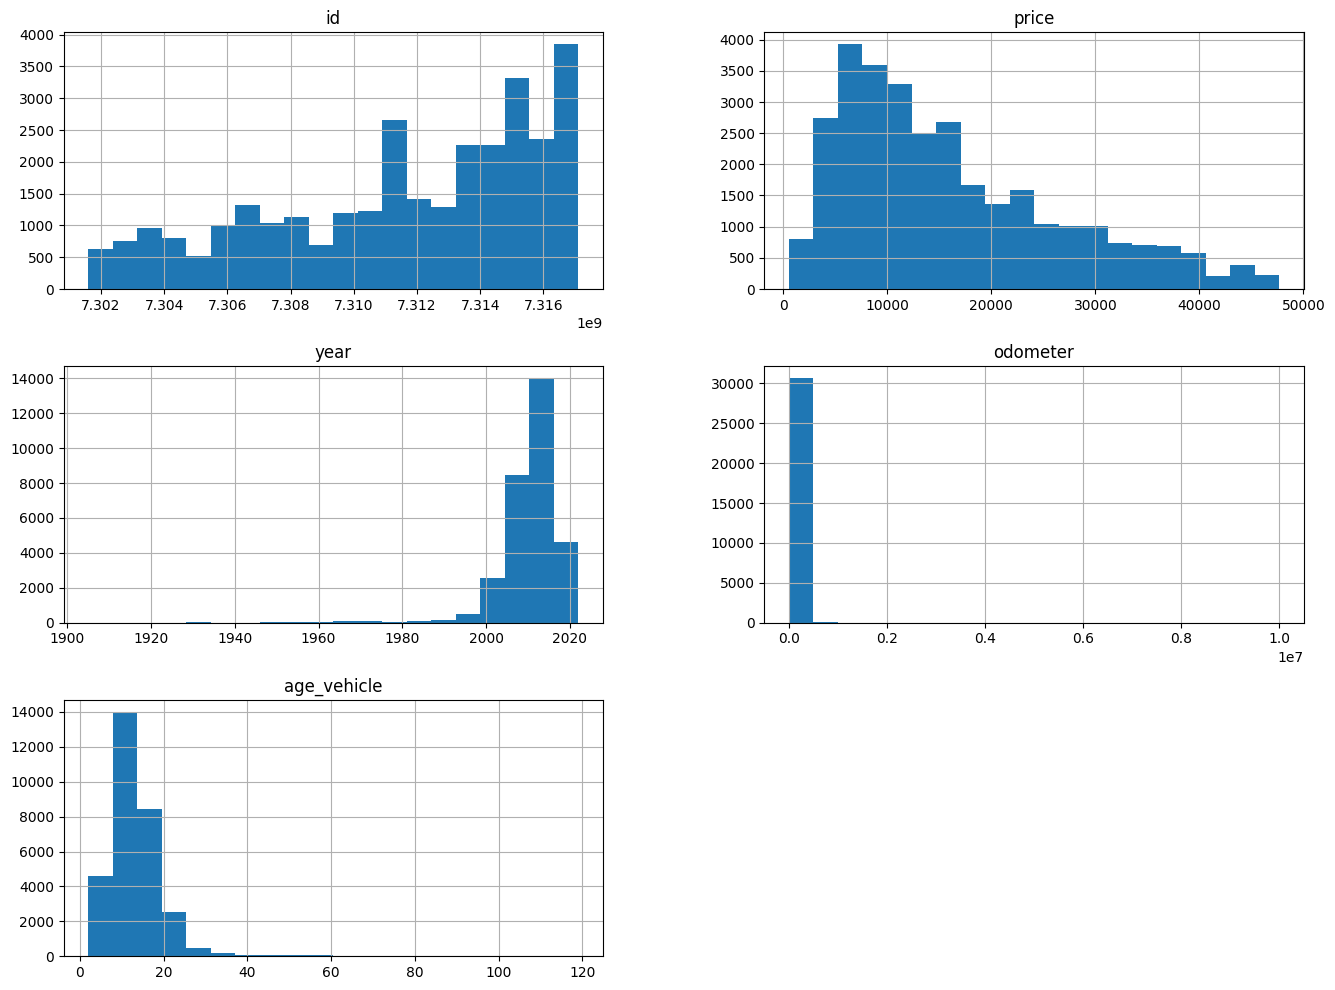

In [218]:
vehicle_df_dropna.hist(bins=20, figsize = (16, 12))

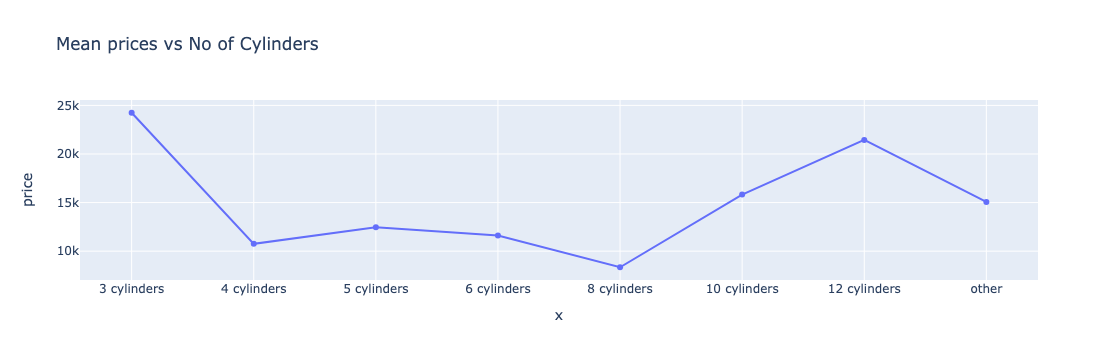

In [219]:
cylinder_list = ['3 cylinders','4 cylinders','5 cylinders','6 cylinders','8 cylinders','10 cylinders', '12 cylinders', 'other']
vehicle_df_cyl = vehicle_df_dropna.groupby('cylinders')[['price']].mean()

fig = px.line(vehicle_df_cyl, x=cylinder_list, y='price', markers=True, title='Mean prices vs No of Cylinders')
fig.show()

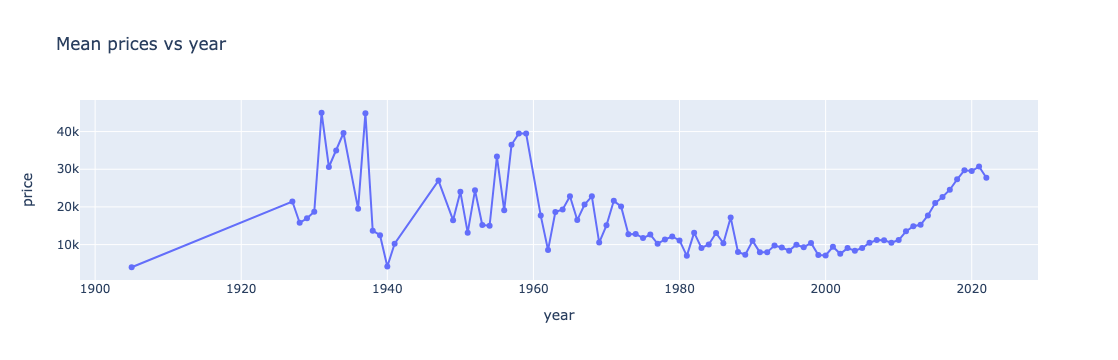

In [220]:
age_veh_list = vehicle_df_dropna['year'].unique().sort()
age_veh_df = vehicle_df_dropna.groupby('year')[['price']].mean()

fig = px.line(age_veh_df, x=age_veh_list, y='price', markers=True, title='Mean prices vs year')
fig.show()

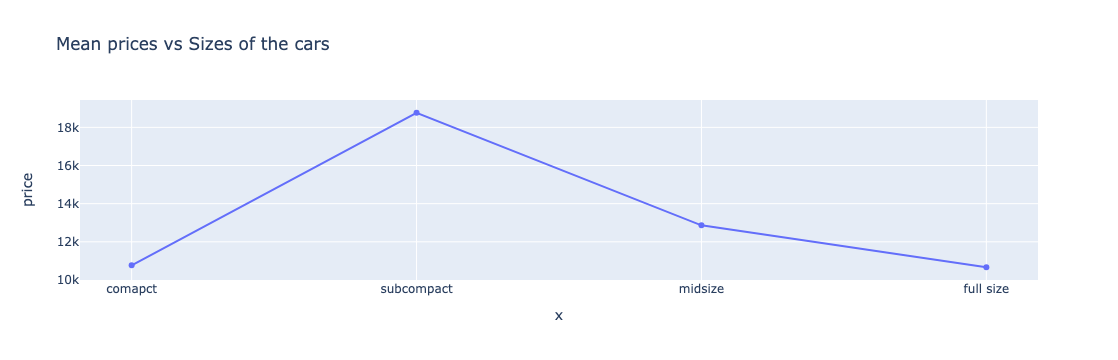

In [221]:
size_list = ['comapct', 'subcompact', 'midsize', 'full size']
size_pr_df = vehicle_df_dropna.groupby('size')[['price']].mean()

px.line(size_pr_df, x=size_list, y='price', markers=True, title=' Mean prices vs Sizes of the cars')

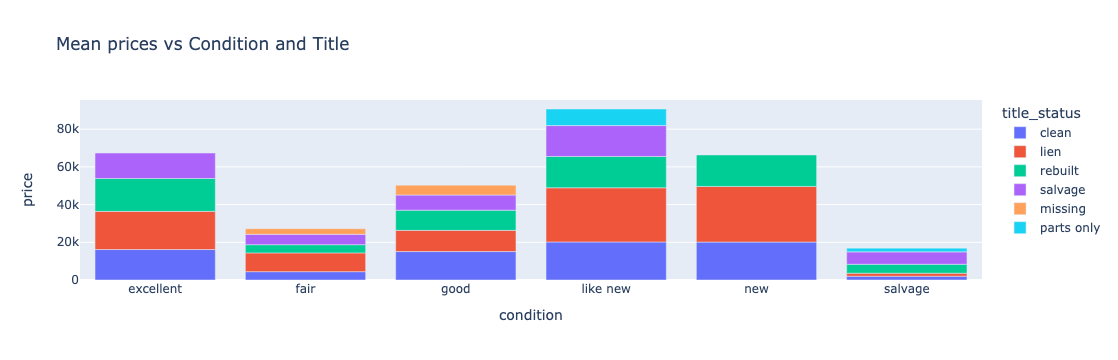

In [222]:
title_df = vehicle_df_dropna.groupby(['condition', 'title_status'])[['price']].mean()
title_df = title_df.reset_index()
title_df

px.bar(title_df, x='condition', y='price',title='Mean prices vs Condition and Title', color='title_status')

In [223]:
#We can drop certain columns : odometer as price and odometer are highly correlated, VIN, region, manufacturer
vehicle_df_dropna.drop(columns=['VIN', 'odometer', 'manufacturer', 'region', 'year', 'id'], inplace=True)

### Modeling

With your (almost?) final dataset in hand, it is now time to build some models.  Here, you should build a number of different regression models with the price as the target.  In building your models, you should explore different parameters and be sure to cross-validate your findings.

In [225]:
##Splitting the data
X = vehicle_df_dropna.drop(columns=['price'])
y = vehicle_df_dropna['price']

In [226]:
vehicle_df_dropna.info()

<class 'pandas.core.frame.DataFrame'>
Index: 30688 entries, 215 to 426833
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   price         30688 non-null  int64  
 1   model         30688 non-null  object 
 2   condition     30688 non-null  object 
 3   cylinders     30688 non-null  object 
 4   fuel          30688 non-null  object 
 5   title_status  30688 non-null  object 
 6   transmission  30688 non-null  object 
 7   drive         30688 non-null  object 
 8   size          30688 non-null  object 
 9   type          30688 non-null  object 
 10  paint_color   30688 non-null  object 
 11  state         30688 non-null  object 
 12  age_vehicle   30688 non-null  float64
dtypes: float64(1), int64(1), object(11)
memory usage: 3.3+ MB


In [227]:
# Convert categorical features to numerical using OneHotEncoding
categorical_features = ['model', 'condition', 'cylinders', 'fuel', 'title_status', 'transmission', 'drive', 'type', 'paint_color', 'size', 'state']
numerical_features = [ 'age_vehicle']

In [228]:
# Defining the column transformer to handle categorical and numerical data
preprocessor = ColumnTransformer(
    transformers=[
        ('numerical', StandardScaler(), numerical_features),
        ('categorical', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

In [229]:
# Defining the models to be used
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(),
    'Lasso Regression': Lasso(alpha=0.02, max_iter=20000)
}

In [230]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=24)

### Evaluation

With some modeling accomplished, we aim to reflect on what we identify as a high quality model and what we are able to learn from this.  We should review our business objective and explore how well we can provide meaningful insight on drivers of used car prices.  Your goal now is to distill your findings and determine whether the earlier phases need revisitation and adjustment or if you have information of value to bring back to your client.

In [ ]:
# Evaluating models using cross-validation and grid search for hyperparameter tuning
results = {}

for model_name, model in models.items():
    try:
        # Creating a pipeline with preprocessor and the model
        pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('model', model)])
        
        # Cross-validation
        cv_val_score = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='r2')
        
        # Fitting the model
        pipeline.fit(X_train, y_train)
        
        # Predicting on the test set
        y_pred = pipeline.predict(X_test)
        
        # Evaluating the model
        mse = mean_squared_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)
        
        # Storing the results
        results[model_name] = {
            'Cross-Validation R^2 Mean': np.mean(cv_val_score),
            'Test R^2': r2,
            'Test MSE': mse
        }
        
        # Printing individual model results
        print(f"{model_name} Results:")
        print(f"Cross-Validation R² Mean: {np.mean(cv_val_score):.4f}")
        print(f"Test R²: {r2:.4f}")
        print(f"Test MSE: {mse:.2f}\n")
    
    except NotFittedError as e:
        print(f"Model {model_name} could not be fitted: {str(e)}")
    except Exception as e:
        print(f"An error occurred with model {model_name}: {str(e)}")


Linear Regression Results:
Cross-Validation R² Mean: 0.6423
Test R²: 0.6780
Test MSE: 35977032.61

Ridge Regression Results:
Cross-Validation R² Mean: 0.6730
Test R²: 0.6977
Test MSE: 33769726.15



In [ ]:
# Converting the results dictionary to a DataFrame
results_df_dropna = pd.DataFrame(results)
print("Summary of Models:")
print(results_df_dropna)

### Deployment

Now that we've settled on our models and findings, it is time to deliver the information to the client.  You should organize your work as a basic report that details your primary findings.  Keep in mind that your audience is a group of used car dealers interested in fine tuning their inventory.

In [ ]:
Below are the findings from above Analysis:

In [ ]:
The prices does show an upward trend after the year of 2000, although declined after the  year 2020 

In [ ]:
Good condition of care depicts the higher mean prices

In [ ]:
Higher Cylinder has higher prices

In [ ]:
Linear Regression model is the best model 